In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

In [19]:
go_biological_processes = pd.read_csv("../results/functional_enrichment/enrichment_GO_Biological_Process_2018.tsv", sep='\t')
go_cellular_components = pd.read_csv("../results/functional_enrichment/enrichment_GO_Cellular_Component_2018.tsv", sep='\t')
go_molecular_functions = pd.read_csv("../results/functional_enrichment/enrichment_GO_Molecular_Function_2018.tsv", sep='\t')
kegg_pathways = pd.read_csv("../results/functional_enrichment/enrichment_KEGG_2018.tsv", sep='\t')

In [20]:
go_biological_processes

,Rank,Term,P-value,Z-score,Combined Score,Overlapping Genes,Adjusted P-value,Old P,Old Adj P
0,1,intracellular protein transport (GO:0006886),0.000528,-1.865713,14.080156,"SSA1, PMT2, ERP2",0.036076,0.016603,0.133350
1,2,cysteine biosynthetic process (GO:0019344),0.006980,-2.589284,12.855005,CYS3,0.036076,0.026864,0.133350
2,3,"protein import into peroxisome matrix, recepto...",0.005986,-2.493005,12.760125,PEX22,0.036076,0.023543,0.133350
3,4,receptor recycling (GO:0001881),0.005986,-2.488386,12.736485,PEX22,0.036076,0.023543,0.133350
4,5,transsulfuration (GO:0019346),0.007973,-2.572824,12.430956,CYS3,0.036076,0.030174,0.133350
...,...,...,...,...,...,...,...,...,...
104,105,"regulation of transcription, DNA-templated (GO...",0.162951,-1.284055,2.329667,FUN19,0.165997,0.460509,0.469116
105,106,proteasome-mediated ubiquitin-dependent protei...,0.135494,-1.164148,2.326927,SSA1,0.142009,0.396141,0.415186
106,107,ribosome biogenesis (GO:0042254),0.162106,-1.083599,1.971615,MAK16,0.165997,0.458598,0.469116
107,108,translation (GO:0006412),0.258715,-1.150867,1.556003,SSA1,0.261111,0.649018,0.655028


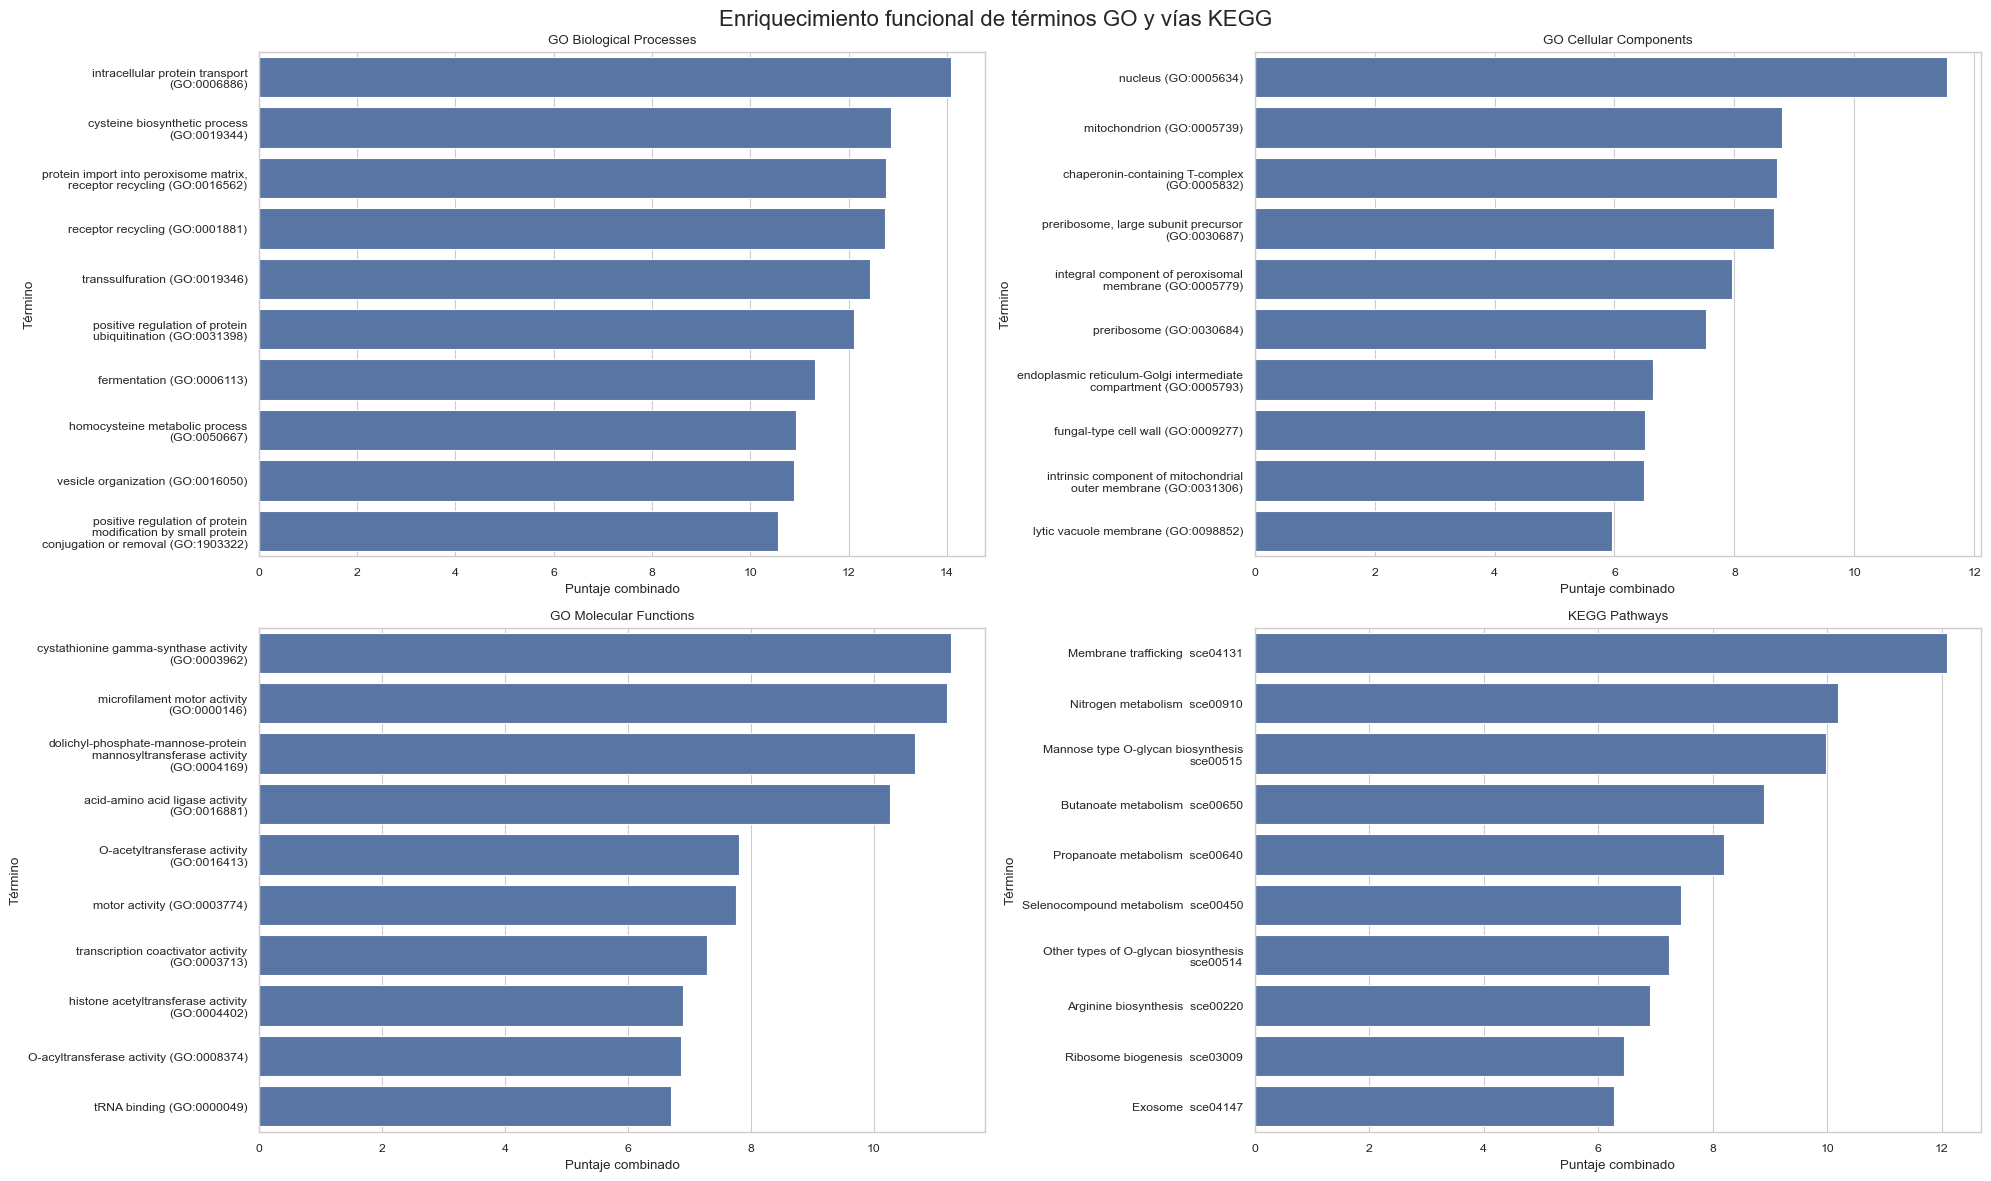

In [40]:
annotations = {
    "GO Biological Processes": go_biological_processes,
    "GO Cellular Components": go_cellular_components,
    "GO Molecular Functions": go_molecular_functions,
    "KEGG Pathways": kegg_pathways
}
sns.set_style("whitegrid")
sns.set_context("paper")
index = 1
height_per_bar = 0.3
plt.figure(figsize=(20, 40 * height_per_bar))
for name, df in annotations.items():
    df["Term"] = df["Term"].apply(lambda x: "\n".join(textwrap.wrap(x, 40)))
    plt.subplot(2, 2, index)
    index += 1
    sns.barplot(df.head(10), x="Combined Score", y="Term")
    plt.title(name)
    plt.xlabel("Puntaje combinado")
    plt.ylabel("Término")

plt.suptitle("Enriquecimiento funcional de términos GO y vías KEGG", fontsize=16)
plt.tight_layout()
plt.show()